Classification with a ResNet 50 trained on ImageNet

In [1]:
!pip install -q torch torchvision pandas Pillow

import urllib
from PIL import Image
from torchvision import transforms
import torch.nn
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


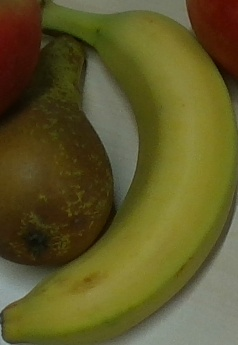

In [7]:
filename = '/content/drive/MyDrive/Deep Learning/fruit-detection-project/image_3.jpg'
img = Image.open(filename).convert('RGB')
img

In [8]:
from torchvision.models import resnet50, ResNet50_Weights

#TODO: Check the documentation and create a resnet50 with ImageNet (IMAGENET1K_V2) weights
weights = ResNet50_Weights.IMAGENET1K_V2
resnet50 = resnet50(weights=weights)

# setting the ResNet to eval() disables dropout and sets BatchNorm layers to training mode
resnet50.eval()

# print the architecture
resnet50

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [9]:
transform = weights.transforms()
print(transform)

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


Original image type and size: <class 'PIL.Image.Image'>, (238, 345)
New image type and size: <class 'torch.Tensor'>, torch.Size([1, 3, 224, 224])
min: -1.95 max: 0.88, mean: -0.77, std: 0.65


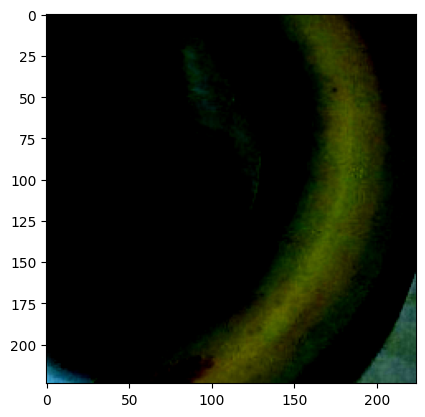

In [10]:
print(f"Original image type and size: {type(img)}, {img.size}")
tensor = transform(img).unsqueeze(0) # transform and add batch dimension
print(f"New image type and size: {type(tensor)}, {tensor.shape}")
print(f"min: {tensor.min():.2f} max: {tensor.max():.2f}, mean: {tensor.mean():.2f}, std: {tensor.std():.2f}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.imshow(tensor.numpy()[0].transpose(1,2,0))

In [11]:
categories = weights.meta["categories"]
# classes
print(", ".join(categories))

tench, goldfish, great white shark, tiger shark, hammerhead, electric ray, stingray, cock, hen, ostrich, brambling, goldfinch, house finch, junco, indigo bunting, robin, bulbul, jay, magpie, chickadee, water ouzel, kite, bald eagle, vulture, great grey owl, European fire salamander, common newt, eft, spotted salamander, axolotl, bullfrog, tree frog, tailed frog, loggerhead, leatherback turtle, mud turtle, terrapin, box turtle, banded gecko, common iguana, American chameleon, whiptail, agama, frilled lizard, alligator lizard, Gila monster, green lizard, African chameleon, Komodo dragon, African crocodile, American alligator, triceratops, thunder snake, ringneck snake, hognose snake, green snake, king snake, garter snake, water snake, vine snake, night snake, boa constrictor, rock python, Indian cobra, green mamba, sea snake, horned viper, diamondback, sidewinder, trilobite, harvestman, scorpion, black and gold garden spider, barn spider, garden spider, black widow, tarantula, wolf spide

In [12]:
with torch.no_grad(): # this is optional, but reduces computations (no gradients)
    # TODO: predict a class probability using the image tensor and resnet50
    logits = resnet50(tensor)
    y_scores = torch.nn.functional.softmax(logits, dim=1)